In [1]:
from games.nocca_nocca.nocca_nocca import NoccaNocca
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax   

In [2]:
game = NoccaNocca(max_steps=150, initial_player=0, seed=1)

In [3]:
agents = {
    game.agents[0]: MiniMax(game=game, agent=game.agents[0], depth=1),
    game.agents[1]: MiniMax(game=game, agent=game.agents[1], depth=1),
}

In [4]:
game.reset()
print(f"Initial Agent: {game.agent_selection}")
while not game.game_over():
    game.render()
    action = agents[game.agent_selection].action()
    print(f"Turn {game.steps} -- Agent {game.agent_selection} plays action {action}")
    game.step(action=action)
game.render()
if game.truncated():
    print("Game was truncated")
for agent in agents:
    print(f"Reward agent {agent}: {game.reward(agent)}")
print(f"The winner is: {game.check_for_winner()}")

Initial Agent: Black
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ 0__ 0__ 0__ 
2: ___ ___ ___ ___ ___ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ ___ ___ 
6: 1__ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 0 -- Agent Black plays action 60
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ ___ 0__ 0__ 
2: ___ 0__ ___ ___ ___ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ ___ ___ ___ ___ 
6: 1__ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 1 -- Agent White plays action 247
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ ___ 0__ 0__ 
2: ___ 0__ ___ ___ ___ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ 1__ ___ ___ ___ 
6: ___ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 2 -- Agent Black plays action 73
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ ___ 0__ ___ 
2: ___ 0__ ___ ___ 0__ 
3: ___ ___ ___ ___ ___ 
4: ___ ___ ___ ___ ___ 
5: ___ 1__ ___ ___ ___ 
6: ___ 1__ 1__ 1__ 1__ 
7: ___ ___ ___ ___ ___ 
Turn 3 -- Agent White plays action 215
0: ___ ___ ___ ___ ___ 
1: 0__ 0__ ___ 0__ ___ 
2: ___ 0_

## Validación: MiniMax y MCTS

Experimentos compactos variando algoritmo, parámetros, jugador inicial y función de evaluación.

In [5]:
from games.nocca_nocca.nocca_nocca import NoccaNocca
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax
from agents.mcts_t import MonteCarloTreeSearch
import numpy as np


def mobility_eval(game, agent):
    current_agent = game.agent_selection
    game.agent_selection = agent
    own_moves = len(game.available_actions())
    opponent = [a for a in game.agents if a != agent][0]
    game.agent_selection = opponent
    opponent_moves = len(game.available_actions())
    game.agent_selection = current_agent
    return (own_moves - opponent_moves) / max(own_moves + opponent_moves, 1)


def run_match(game, players):
    game.reset()
    while not game.game_over():
        game.step(players[game.agent_selection].action())
    return {agent: game.reward(agent) for agent in game.agents}


def evaluate_nocca(make_game, make_players, n=5):
    rewards = {agent: [] for agent in make_game().agents}
    for _ in range(n):
        game = make_game()
        players = make_players(game)
        result = run_match(game, players)
        for agent, reward in result.items():
            rewards[agent].append(reward)
    return {agent: np.mean(values) for agent, values in rewards.items()}

In [6]:
experiments = []
N = 5

for initial_player in [0, 1]:
    for depth in [1, 2]:
        experiments.append((
            f"p{initial_player}: MiniMax depth={depth} vs Random",
            lambda initial_player=initial_player: NoccaNocca(max_steps=80, initial_player=initial_player, seed=1),
            lambda game, depth=depth: {
                game.agents[0]: MiniMax(game, game.agents[0], depth=depth),
                game.agents[1]: RandomAgent(game, game.agents[1]),
            }
        ))
        experiments.append((
            f"p{initial_player}: Random vs MiniMax depth={depth}",
            lambda initial_player=initial_player: NoccaNocca(max_steps=80, initial_player=initial_player, seed=1),
            lambda game, depth=depth: {
                game.agents[0]: RandomAgent(game, game.agents[0]),
                game.agents[1]: MiniMax(game, game.agents[1], depth=depth),
            }
        ))

    for simulations, rollouts in [(5, 1), (10, 2)]:
        experiments.append((
            f"p{initial_player}: MCTS sim={simulations}, rollouts={rollouts} vs Random",
            lambda initial_player=initial_player: NoccaNocca(max_steps=80, initial_player=initial_player, seed=1),
            lambda game, simulations=simulations, rollouts=rollouts: {
                game.agents[0]: MonteCarloTreeSearch(game, game.agents[0], simulations=simulations, rollouts=rollouts),
                game.agents[1]: RandomAgent(game, game.agents[1]),
            }
        ))
        experiments.append((
            f"p{initial_player}: Random vs MCTS sim={simulations}, rollouts={rollouts}",
            lambda initial_player=initial_player: NoccaNocca(max_steps=80, initial_player=initial_player, seed=1),
            lambda game, simulations=simulations, rollouts=rollouts: {
                game.agents[0]: RandomAgent(game, game.agents[0]),
                game.agents[1]: MonteCarloTreeSearch(game, game.agents[1], simulations=simulations, rollouts=rollouts),
            }
        ))

experiments.append((
    "p0: MiniMax depth=1 con eval movilidad",
    lambda: NoccaNocca(max_steps=80, initial_player=0, seed=1),
    lambda game: (
        setattr(game, "eval", lambda agent: mobility_eval(game, agent)) or {
            game.agents[0]: MiniMax(game, game.agents[0], depth=1),
            game.agents[1]: MiniMax(game, game.agents[1], depth=1),
        }
    )
))

for name, make_game, make_players in experiments:
    scores = evaluate_nocca(make_game, make_players, n=N)
    print(name, scores)

p0: MiniMax depth=1 vs Random {'Black': np.float64(1.0), 'White': np.float64(-1.0)}
p0: Random vs MiniMax depth=1 {'Black': np.float64(-1.0), 'White': np.float64(1.0)}
p0: MiniMax depth=2 vs Random {'Black': np.float64(1.0), 'White': np.float64(-1.0)}
p0: Random vs MiniMax depth=2 {'Black': np.float64(-1.0), 'White': np.float64(1.0)}
p0: MCTS sim=5, rollouts=1 vs Random {'Black': np.float64(0.0), 'White': np.float64(0.0)}
p0: Random vs MCTS sim=5, rollouts=1 {'Black': np.float64(-0.2), 'White': np.float64(0.2)}
p0: MCTS sim=10, rollouts=2 vs Random {'Black': np.float64(1.0), 'White': np.float64(-1.0)}
p0: Random vs MCTS sim=10, rollouts=2 {'Black': np.float64(-0.6), 'White': np.float64(0.6)}
p1: MiniMax depth=1 vs Random {'Black': np.float64(1.0), 'White': np.float64(-1.0)}
p1: Random vs MiniMax depth=1 {'Black': np.float64(-1.0), 'White': np.float64(1.0)}
p1: MiniMax depth=2 vs Random {'Black': np.float64(1.0), 'White': np.float64(-1.0)}
p1: Random vs MiniMax depth=2 {'Black': np.floa

## Experimentos completos: MiniMax y MCTS

Nocca-Nocca tiene un espacio de acciones bastante mayor que Tic-Tac-Toe: cada pieza puede moverse en varias direcciones y además puede apilarse. Por eso los valores por defecto de profundidad, simulaciones y partidas son más bajos.

La evaluación base de `NoccaNocca.eval` usa progreso promedio hacia la meta y penaliza piezas bloqueadas. La evaluación alternativa de abajo agrega una señal relativa: compara el progreso de la pieza más avanzada, el progreso promedio, la movilidad y el bloqueo propio contra los mismos indicadores del rival.

In [7]:
from time import perf_counter
from games.nocca_nocca.nocca_nocca import NoccaNocca
from games.nocca_nocca.board import Board
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax
from agents.mcts_t import MonteCarloTreeSearch
import numpy as np


class NoccaNoccaRelativeEval(NoccaNocca):
    def _mobility(self, agent):
        current_agent = self.agent_selection
        self.agent_selection = agent
        moves = len(self.available_actions())
        self.agent_selection = current_agent
        return moves

    def eval(self, agent):
        if agent not in self.agents:
            raise ValueError(f"Agent {agent} is not part of the game.")
        if self.terminated():
            return self.rewards[agent]

        opponent = [a for a in self.agents if a != agent][0]
        own_mobility = self._mobility(agent)
        opp_mobility = self._mobility(opponent)
        mobility = (own_mobility - opp_mobility) / max(own_mobility + opp_mobility, 1)

        own_score = 0.50 * self._eval_closest_to_goal(agent) + 0.30 * self._eval_progress(agent) - 0.20 * self._eval_blocked(agent)
        opp_score = 0.50 * self._eval_closest_to_goal(opponent) + 0.30 * self._eval_progress(opponent) - 0.20 * self._eval_blocked(opponent)
        return max(-1.0, min(1.0, own_score - opp_score + 0.20 * mobility))

    def clone(self):
        self_clone = NoccaNoccaRelativeEval(
            initial_player=self.initial_player,
            max_steps=self.max_steps,
            seed=self.seed,
            render_mode=self.render_mode,
        )
        self_clone.board = Board()
        self_clone.board.set_board(self.board)
        self_clone.rewards = self.rewards.copy()
        self_clone.terminations = self.terminations.copy()
        self_clone.truncations = self.truncations.copy()
        self_clone.infos = self.infos.copy()
        self_clone.agent_selection = self.agent_selection
        self_clone.steps = self.steps
        return self_clone


def run_nocca_match(game, players):
    game.reset()
    while not game.game_over():
        game.step(players[game.agent_selection].action())
    return {
        "rewards": {agent: game.reward(agent) for agent in game.agents},
        "winner": game.check_for_winner(),
        "truncated": game.truncated(),
        "steps": game.steps,
    }


def summarize_nocca(make_game, make_players, n_games=3):
    sample = make_game()
    wins = {sample.agents[0]: 0, sample.agents[1]: 0, "draws": 0, "truncated": 0}
    rewards = {agent: [] for agent in sample.agents}
    steps = []
    start = perf_counter()

    for _ in range(n_games):
        game = make_game()
        players = make_players(game)
        result = run_nocca_match(game, players)
        for agent, reward in result["rewards"].items():
            rewards[agent].append(reward)
        if result["winner"] is None:
            wins["draws"] += 1
        else:
            wins[result["winner"]] += 1
        if result["truncated"]:
            wins["truncated"] += 1
        steps.append(result["steps"])

    elapsed = perf_counter() - start
    avg_rewards = {agent: np.mean(values) for agent, values in rewards.items()}
    return wins, avg_rewards, np.mean(steps), elapsed

In [8]:
MAX_DEPTH = 2
N_GAMES = 3
MAX_STEPS = 80

for eval_name, game_cls in [("eval base", NoccaNocca), ("eval relativa", NoccaNoccaRelativeEval)]:
    print(f"\n=== MiniMax vs MiniMax - {eval_name} ===")
    for initial_player in [0, 1]:
        for depth_black in range(1, MAX_DEPTH + 1):
            for depth_white in range(1, MAX_DEPTH + 1):
                wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
                    make_game=lambda initial_player=initial_player, game_cls=game_cls: game_cls(
                        max_steps=MAX_STEPS,
                        initial_player=initial_player,
                        seed=1,
                        render_mode='',
                    ),
                    make_players=lambda game, depth_black=depth_black, depth_white=depth_white: {
                        game.agents[0]: MiniMax(game, game.agents[0], depth=depth_black),
                        game.agents[1]: MiniMax(game, game.agents[1], depth=depth_white),
                    },
                    n_games=N_GAMES,
                )
                print(
                    f"p{initial_player} | Black depth={depth_black} vs White depth={depth_white} | "
                    f"wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s"
                )


=== MiniMax vs MiniMax - eval base ===
p0 | Black depth=1 vs White depth=1 | wins={'Black': 2, 'White': 1, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(0.3333333333333333), 'White': np.float64(-0.3333333333333333)} | steps=26.0 | tiempo=1.543s
p0 | Black depth=1 vs White depth=2 | wins={'Black': 1, 'White': 2, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-0.3333333333333333), 'White': np.float64(0.3333333333333333)} | steps=27.7 | tiempo=14.982s
p0 | Black depth=2 vs White depth=1 | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=30.7 | tiempo=21.096s
p0 | Black depth=2 vs White depth=2 | wins={'Black': 2, 'White': 1, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(0.3333333333333333), 'White': np.float64(-0.3333333333333333)} | steps=26.7 | tiempo=39.209s
p1 | Black depth=1 vs White depth=1 | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0

### Visualización: MiniMax vs MiniMax con diferentes profundidades

Gráfico mostrando los resultados de MiniMax contra MiniMax con diferentes combinaciones de profundidad y funciones de evaluación.

Ejecutando comparaciones MiniMax vs MiniMax...


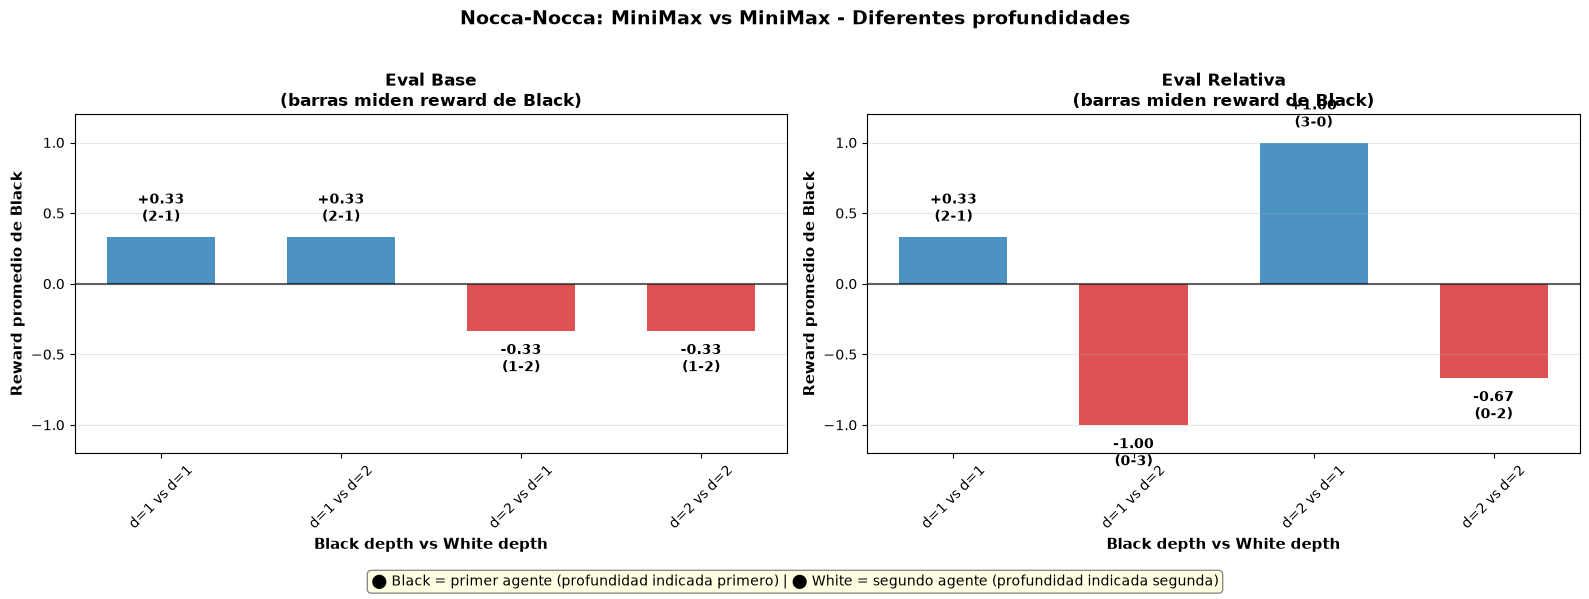


INTERPRETACION
• Black y White son ambos MiniMax con diferentes profundidades
• Se prueban dos funciones de evaluacion: base y relativa
• Valores POSITIVOS (azul): Black gana mas
• Valores NEGATIVOS (rojo): White gana mas
• Valores cercanos a 0: juego equilibrado

Mejor resultado para Black: d=2 vs d=1 (eval relativa) → +1.00
Peor resultado para Black: d=1 vs d=2 (eval relativa) → -1.00
Configuraciones equilibradas (|reward| < 0.1): 0


In [9]:
# Visualización de MiniMax vs MiniMax con diferentes profundidades
import matplotlib.pyplot as plt
import numpy as np

MAX_DEPTH = 2
N_GAMES = 3
MAX_STEPS = 80

print("Ejecutando comparaciones MiniMax vs MiniMax...")

# Experimentos a visualizar (solo con initial_player=0 para simplificar)
minimax_comparisons = []

for eval_name, game_cls in [("eval base", NoccaNocca), ("eval relativa", NoccaNoccaRelativeEval)]:
    for depth_black in range(1, MAX_DEPTH + 1):
        for depth_white in range(1, MAX_DEPTH + 1):
            wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
                make_game=lambda game_cls=game_cls: game_cls(
                    max_steps=MAX_STEPS,
                    initial_player=0,
                    seed=42,
                    render_mode='',
                ),
                make_players=lambda game, depth_black=depth_black, depth_white=depth_white: {
                    game.agents[0]: MiniMax(game, game.agents[0], depth=depth_black),
                    game.agents[1]: MiniMax(game, game.agents[1], depth=depth_white),
                },
                n_games=N_GAMES,
            )
            minimax_comparisons.append({
                'label': f"d={depth_black} vs d={depth_white}",
                'eval': eval_name,
                'black_avg': avg_rewards[game.agents[0]],
                'wins': wins,
            })

# Separar por función de evaluación
eval_base_results = [r for r in minimax_comparisons if r['eval'] == "eval base"]
eval_rel_results = [r for r in minimax_comparisons if r['eval'] == "eval relativa"]

# Crear dos subgráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, eval_name in [(ax1, eval_base_results, "Eval Base"), (ax2, eval_rel_results, "Eval Relativa")]:
    labels = [r['label'] for r in results]
    black_values = [r['black_avg'] for r in results]
    
    colors = ['tab:blue' if v >= 0 else 'tab:red' for v in black_values]
    bars = ax.bar(labels, black_values, color=colors, alpha=0.8, width=0.6)
    
    # Agregar valores numéricos
    for bar, value, result in zip(bars, black_values, results):
        offset = 0.08 if value >= 0 else -0.08
        va = 'bottom' if value >= 0 else 'top'
        wins_text = f"{result['wins']['Black']}-{result['wins']['White']}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f'{value:+.2f}\n({wins_text})',
            ha='center',
            va=va,
            fontsize=10,
            fontweight='bold'
        )
    
    ax.axhline(0, color='black', linewidth=1.5, alpha=0.6)
    ax.set_title(f'{eval_name}\n(barras miden reward de Black)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Reward promedio de Black', fontsize=11, fontweight='bold')
    ax.set_xlabel('Black depth vs White depth', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

# Título general
fig.suptitle('Nocca-Nocca: MiniMax vs MiniMax - Diferentes profundidades', 
             fontsize=14, fontweight='bold', y=0.98)

# Leyenda común
fig.text(0.5, 0.02, 
         '⬤ Black = primer agente (profundidad indicada primero) | ⬤ White = segundo agente (profundidad indicada segunda)',
         ha='center', fontsize=10,
         bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'})

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

# Interpretación
best = max(minimax_comparisons, key=lambda r: r['black_avg'])
worst = min(minimax_comparisons, key=lambda r: r['black_avg'])
balanced = [r for r in minimax_comparisons if abs(r['black_avg']) < 0.1]

print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• Black y White son ambos MiniMax con diferentes profundidades\n"
    f"• Se prueban dos funciones de evaluacion: base y relativa\n"
    f"• Valores POSITIVOS (azul): Black gana mas\n"
    f"• Valores NEGATIVOS (rojo): White gana mas\n"
    f"• Valores cercanos a 0: juego equilibrado\n\n"
    f"Mejor resultado para Black: {best['label']} ({best['eval']}) → {best['black_avg']:+.2f}\n"
    f"Peor resultado para Black: {worst['label']} ({worst['eval']}) → {worst['black_avg']:+.2f}\n"
    f"Configuraciones equilibradas (|reward| < 0.1): {len(balanced)}\n"
    + '='*80
)

In [10]:
N_GAMES = 5
MAX_STEPS = 80

for initial_player in [0, 1]:
    print(f"\n=== Contra Random | initial_player={initial_player} ===")

    for depth in [1, 2]:
        for label, make_players in [
            (
                f"MiniMax depth={depth} vs Random",
                lambda game, depth=depth: {
                    game.agents[0]: MiniMax(game, game.agents[0], depth=depth),
                    game.agents[1]: RandomAgent(game, game.agents[1]),
                },
            ),
            (
                f"Random vs MiniMax depth={depth}",
                lambda game, depth=depth: {
                    game.agents[0]: RandomAgent(game, game.agents[0]),
                    game.agents[1]: MiniMax(game, game.agents[1], depth=depth),
                },
            ),
        ]:
            wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
                make_game=lambda initial_player=initial_player: NoccaNocca(max_steps=MAX_STEPS, initial_player=initial_player, seed=1, render_mode=''),
                make_players=make_players,
                n_games=N_GAMES,
            )
            print(f"{label} | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")

    for simulations, rollouts in [(5, 1), (10, 2)]:
        for label, make_players in [
            (
                f"MCTS sim={simulations}, rollouts={rollouts} vs Random",
                lambda game, simulations=simulations, rollouts=rollouts: {
                    game.agents[0]: MonteCarloTreeSearch(game, game.agents[0], simulations=simulations, rollouts=rollouts),
                    game.agents[1]: RandomAgent(game, game.agents[1]),
                },
            ),
            (
                f"Random vs MCTS sim={simulations}, rollouts={rollouts}",
                lambda game, simulations=simulations, rollouts=rollouts: {
                    game.agents[0]: RandomAgent(game, game.agents[0]),
                    game.agents[1]: MonteCarloTreeSearch(game, game.agents[1], simulations=simulations, rollouts=rollouts),
                },
            ),
        ]:
            wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
                make_game=lambda initial_player=initial_player: NoccaNocca(max_steps=MAX_STEPS, initial_player=initial_player, seed=1, render_mode=''),
                make_players=make_players,
                n_games=N_GAMES,
            )
            print(f"{label} | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")


=== Contra Random | initial_player=0 ===
MiniMax depth=1 vs Random | wins={'Black': 5, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=28.2 | tiempo=0.959s
Random vs MiniMax depth=1 | wins={'Black': 0, 'White': 5, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=22.0 | tiempo=0.679s
MiniMax depth=2 vs Random | wins={'Black': 5, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=48.6 | tiempo=37.278s
Random vs MiniMax depth=2 | wins={'Black': 0, 'White': 5, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=49.2 | tiempo=38.100s
MCTS sim=5, rollouts=1 vs Random | wins={'Black': 4, 'White': 1, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(0.6), 'White': np.float64(-0.6)} | steps=63.6 | tiempo=36.725s
Random vs MCTS sim=5, rollouts=1 | wins={'Black': 0, 'White': 4, 'draws':

Ejecutando comparaciones contra Random...


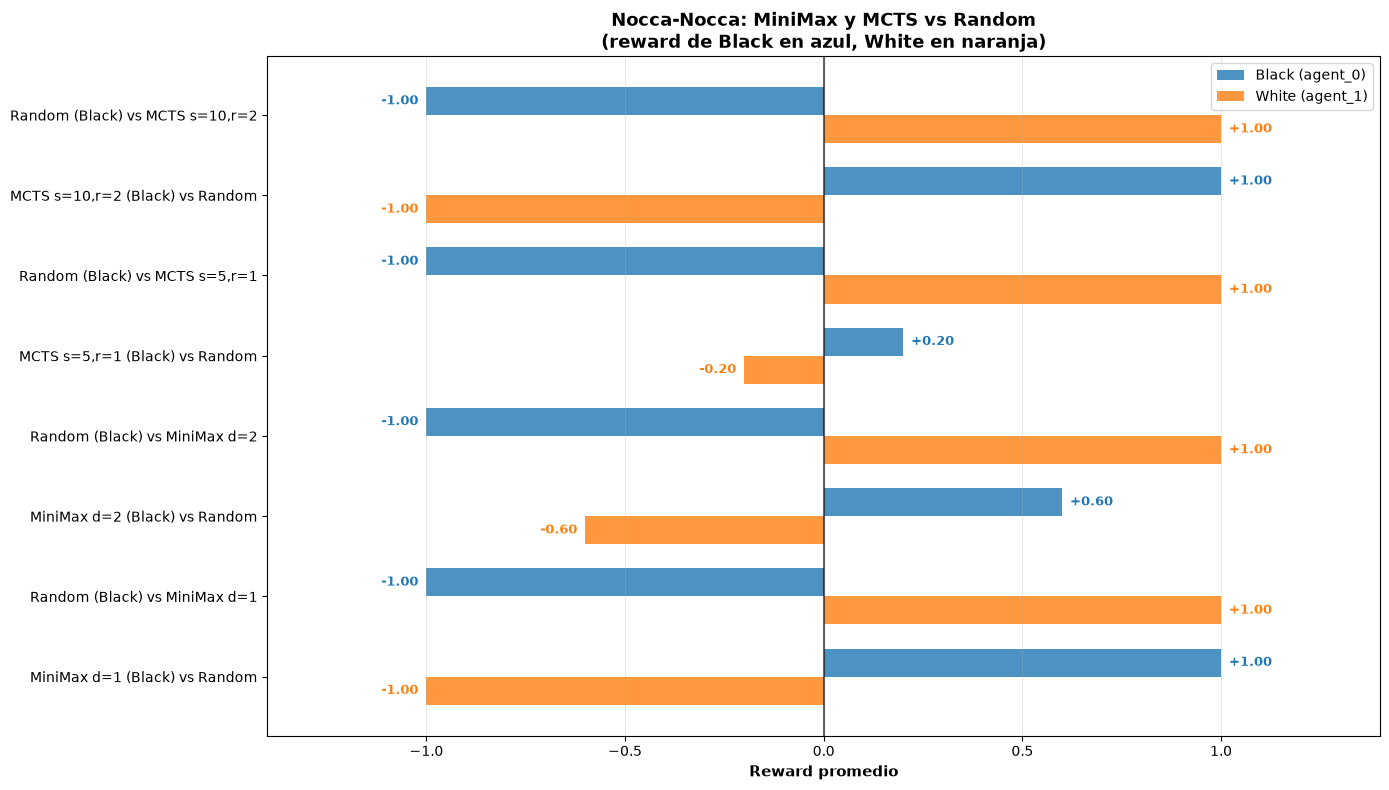


Mejor resultado para Black: MiniMax d=1 (Black) vs Random → +1.00
Peor resultado para Black:  Random (Black) vs MiniMax d=1 → -1.00


In [11]:
# Visualización: MiniMax y MCTS vs Random
import matplotlib.pyplot as plt
import numpy as np

N_GAMES = 5
MAX_STEPS = 80
INITIAL_PLAYER = 0

print("Ejecutando comparaciones contra Random...")

vs_random_results = []

for depth in [1, 2]:
    for label, make_players in [
        (
            f"MiniMax d={depth} (Black) vs Random",
            lambda game, depth=depth: {
                game.agents[0]: MiniMax(game, game.agents[0], depth=depth),
                game.agents[1]: RandomAgent(game, game.agents[1]),
            },
        ),
        (
            f"Random (Black) vs MiniMax d={depth}",
            lambda game, depth=depth: {
                game.agents[0]: RandomAgent(game, game.agents[0]),
                game.agents[1]: MiniMax(game, game.agents[1], depth=depth),
            },
        ),
    ]:
        wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
            make_game=lambda: NoccaNocca(max_steps=MAX_STEPS, initial_player=INITIAL_PLAYER, seed=42, render_mode=''),
            make_players=make_players,
            n_games=N_GAMES,
        )
        game_ref = NoccaNocca(max_steps=MAX_STEPS, initial_player=INITIAL_PLAYER, seed=42, render_mode='')
        vs_random_results.append({
            'label': label,
            'black_avg': avg_rewards[game_ref.agents[0]],
            'white_avg': avg_rewards[game_ref.agents[1]],
            'wins': wins,
            'time': elapsed,
        })

for simulations, rollouts in [(5, 1), (10, 2)]:
    for label, make_players in [
        (
            f"MCTS s={simulations},r={rollouts} (Black) vs Random",
            lambda game, s=simulations, r=rollouts: {
                game.agents[0]: MonteCarloTreeSearch(game, game.agents[0], simulations=s, rollouts=r),
                game.agents[1]: RandomAgent(game, game.agents[1]),
            },
        ),
        (
            f"Random (Black) vs MCTS s={simulations},r={rollouts}",
            lambda game, s=simulations, r=rollouts: {
                game.agents[0]: RandomAgent(game, game.agents[0]),
                game.agents[1]: MonteCarloTreeSearch(game, game.agents[1], simulations=s, rollouts=r),
            },
        ),
    ]:
        wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
            make_game=lambda: NoccaNocca(max_steps=MAX_STEPS, initial_player=INITIAL_PLAYER, seed=42, render_mode=''),
            make_players=make_players,
            n_games=N_GAMES,
        )
        game_ref = NoccaNocca(max_steps=MAX_STEPS, initial_player=INITIAL_PLAYER, seed=42, render_mode='')
        vs_random_results.append({
            'label': label,
            'black_avg': avg_rewards[game_ref.agents[0]],
            'white_avg': avg_rewards[game_ref.agents[1]],
            'wins': wins,
            'time': elapsed,
        })

# Horizontal bar chart
labels = [r['label'] for r in vs_random_results]
black_vals = [r['black_avg'] for r in vs_random_results]
white_vals = [r['white_avg'] for r in vs_random_results]

y = np.arange(len(labels))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

bars_black = ax.barh(y + bar_h / 2, black_vals, bar_h, label='Black (agent_0)', color='tab:blue', alpha=0.8)
bars_white = ax.barh(y - bar_h / 2, white_vals, bar_h, label='White (agent_1)', color='tab:orange', alpha=0.8)

for bar, val in zip(bars_black, black_vals):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=9, fontweight='bold', color='tab:blue')

for bar, val in zip(bars_white, white_vals):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=9, fontweight='bold', color='tab:orange')

ax.axvline(0, color='black', linewidth=1.5, alpha=0.6)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Reward promedio', fontsize=11, fontweight='bold')
ax.set_title(
    'Nocca-Nocca: MiniMax y MCTS vs Random\n(reward de Black en azul, White en naranja)',
    fontsize=13, fontweight='bold',
)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(-1.4, 1.4)
plt.tight_layout()
plt.show()

best = max(vs_random_results, key=lambda r: r['black_avg'])
print(f"\nMejor resultado para Black: {best['label']} → {best['black_avg']:+.2f}")
worst = min(vs_random_results, key=lambda r: r['black_avg'])
print(f"Peor resultado para Black:  {worst['label']} → {worst['black_avg']:+.2f}")

In [12]:
N_GAMES = 3
MAX_STEPS = 80

for initial_player in [0, 1]:
    print(f"\n=== MCTS vs MiniMax | initial_player={initial_player} ===")
    for depth in [1, 2]:
        for simulations, rollouts in [(5, 1), (10, 2)]:
            for label, make_players in [
                (
                    f"MCTS sim={simulations}, rollouts={rollouts} vs MiniMax depth={depth}",
                    lambda game, depth=depth, simulations=simulations, rollouts=rollouts: {
                        game.agents[0]: MonteCarloTreeSearch(game, game.agents[0], simulations=simulations, rollouts=rollouts),
                        game.agents[1]: MiniMax(game, game.agents[1], depth=depth),
                    },
                ),
                (
                    f"MiniMax depth={depth} vs MCTS sim={simulations}, rollouts={rollouts}",
                    lambda game, depth=depth, simulations=simulations, rollouts=rollouts: {
                        game.agents[0]: MiniMax(game, game.agents[0], depth=depth),
                        game.agents[1]: MonteCarloTreeSearch(game, game.agents[1], simulations=simulations, rollouts=rollouts),
                    },
                ),
            ]:
                wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
                    make_game=lambda initial_player=initial_player: NoccaNocca(max_steps=MAX_STEPS, initial_player=initial_player, seed=1, render_mode=''),
                    make_players=make_players,
                    n_games=N_GAMES,
                )
                print(f"{label} | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")


=== MCTS vs MiniMax | initial_player=0 ===
MCTS sim=5, rollouts=1 vs MiniMax depth=1 | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=26.7 | tiempo=14.377s
MiniMax depth=1 vs MCTS sim=5, rollouts=1 | wins={'Black': 3, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=31.0 | tiempo=15.562s
MCTS sim=10, rollouts=2 vs MiniMax depth=1 | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=29.3 | tiempo=71.547s
MiniMax depth=1 vs MCTS sim=10, rollouts=2 | wins={'Black': 3, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=29.7 | tiempo=69.720s
MCTS sim=5, rollouts=1 vs MiniMax depth=2 | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=50.7 | tiempo=58

### Visualización: MCTS vs MiniMax

Comparación de MCTS contra MiniMax con diferentes configuraciones, mostrando tanto rewards como tiempos de ejecución.

Ejecutando comparaciones MCTS vs MiniMax...


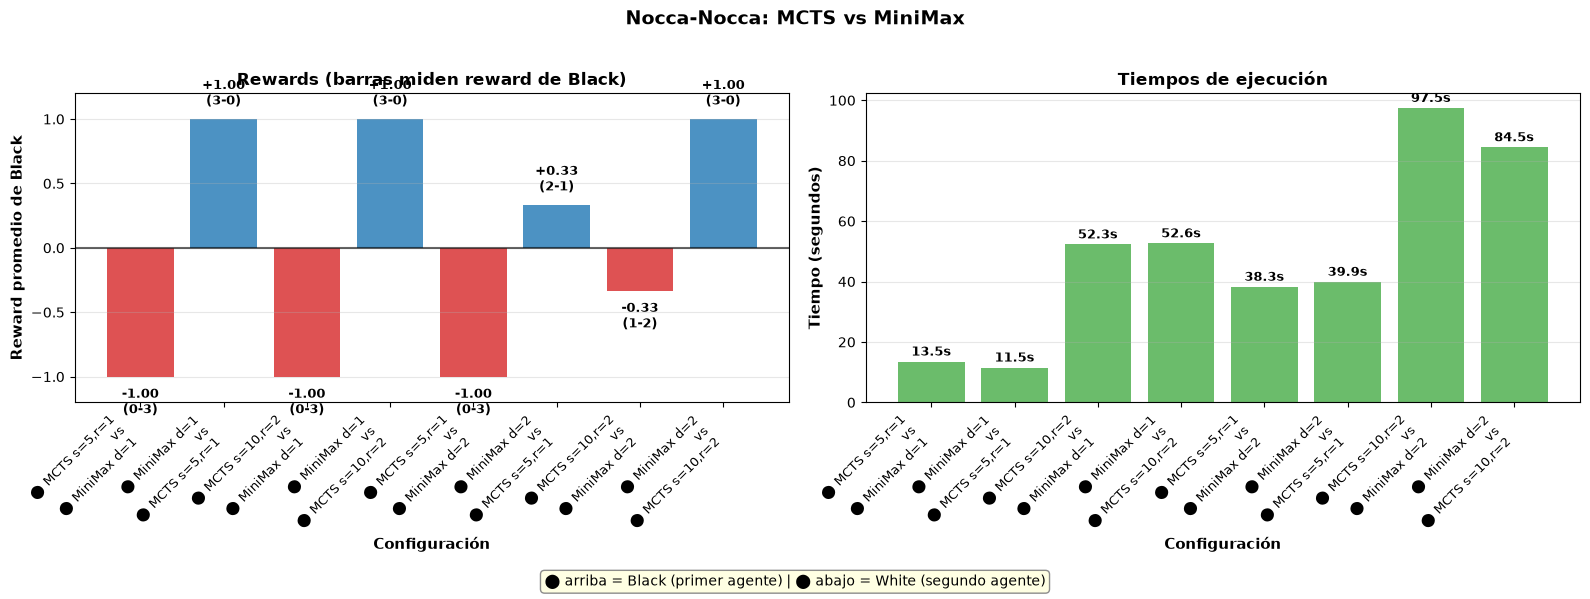


INTERPRETACION
• Black = primer agente, White = segundo agente
• Valores POSITIVOS (azul): Black gana mas
• Valores NEGATIVOS (rojo): White gana mas

REWARDS:
  Mejor para Black: ⬤ MiniMax d=1 vs ⬤ MCTS s=5,r=1 → +1.00
  Peor para Black: ⬤ MCTS s=5,r=1 vs ⬤ MiniMax d=1 → -1.00

TIEMPOS:
  Mas rapido: ⬤ MiniMax d=1 vs ⬤ MCTS s=5,r=1 → 11.5s
  Mas lento: ⬤ MCTS s=10,r=2 vs ⬤ MiniMax d=2 → 97.5s

OBSERVACION: MiniMax depth=1 es generalmente mas rapido que MCTS con
simulaciones altas, pero ambos algoritmos muestran desempeño similar en rewards.


In [13]:
# Visualización de MCTS vs MiniMax
import matplotlib.pyplot as plt
import numpy as np

N_GAMES = 3
MAX_STEPS = 80
INITIAL_PLAYER = 0

print("Ejecutando comparaciones MCTS vs MiniMax...")

# Configuraciones a comparar
mcts_minimax_configs = [
    ("⬤ MCTS s=5,r=1\nvs\n⬤ MiniMax d=1", 
     lambda g: MonteCarloTreeSearch(g, g.agents[0], simulations=5, rollouts=1),
     lambda g: MiniMax(g, g.agents[1], depth=1)),
    ("⬤ MiniMax d=1\nvs\n⬤ MCTS s=5,r=1", 
     lambda g: MiniMax(g, g.agents[0], depth=1),
     lambda g: MonteCarloTreeSearch(g, g.agents[1], simulations=5, rollouts=1)),
    ("⬤ MCTS s=10,r=2\nvs\n⬤ MiniMax d=1", 
     lambda g: MonteCarloTreeSearch(g, g.agents[0], simulations=10, rollouts=2),
     lambda g: MiniMax(g, g.agents[1], depth=1)),
    ("⬤ MiniMax d=1\nvs\n⬤ MCTS s=10,r=2", 
     lambda g: MiniMax(g, g.agents[0], depth=1),
     lambda g: MonteCarloTreeSearch(g, g.agents[1], simulations=10, rollouts=2)),
    ("⬤ MCTS s=5,r=1\nvs\n⬤ MiniMax d=2", 
     lambda g: MonteCarloTreeSearch(g, g.agents[0], simulations=5, rollouts=1),
     lambda g: MiniMax(g, g.agents[1], depth=2)),
    ("⬤ MiniMax d=2\nvs\n⬤ MCTS s=5,r=1", 
     lambda g: MiniMax(g, g.agents[0], depth=2),
     lambda g: MonteCarloTreeSearch(g, g.agents[1], simulations=5, rollouts=1)),
    ("⬤ MCTS s=10,r=2\nvs\n⬤ MiniMax d=2", 
     lambda g: MonteCarloTreeSearch(g, g.agents[0], simulations=10, rollouts=2),
     lambda g: MiniMax(g, g.agents[1], depth=2)),
    ("⬤ MiniMax d=2\nvs\n⬤ MCTS s=10,r=2", 
     lambda g: MiniMax(g, g.agents[0], depth=2),
     lambda g: MonteCarloTreeSearch(g, g.agents[1], simulations=10, rollouts=2)),
]

results = []
for label, make_black, make_white in mcts_minimax_configs:
    wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
        make_game=lambda: NoccaNocca(
            max_steps=MAX_STEPS,
            initial_player=INITIAL_PLAYER,
            seed=42,
            render_mode='',
        ),
        make_players=lambda game, mb=make_black, mw=make_white: {
            game.agents[0]: mb(game),
            game.agents[1]: mw(game),
        },
        n_games=N_GAMES,
    )
    results.append({
        'label': label,
        'black_avg': avg_rewards[game.agents[0]],
        'wins': wins,
        'time': elapsed,
    })

# Crear visualización con dos subgráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

labels = [r['label'] for r in results]
black_values = [r['black_avg'] for r in results]
times = [r['time'] for r in results]

# Gráfica 1: Rewards
colors = ['tab:blue' if v >= 0 else 'tab:red' for v in black_values]
bars1 = ax1.bar(range(len(labels)), black_values, color=colors, alpha=0.8)

for i, (bar, value, result) in enumerate(zip(bars1, black_values, results)):
    offset = 0.08 if value >= 0 else -0.08
    va = 'bottom' if value >= 0 else 'top'
    wins_text = f"{result['wins']['Black']}-{result['wins']['White']}"
    ax1.text(
        i,
        value + offset,
        f'{value:+.2f}\n({wins_text})',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

ax1.axhline(0, color='black', linewidth=1.5, alpha=0.6)
ax1.set_title('Rewards (barras miden reward de Black)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Reward promedio de Black', fontsize=11, fontweight='bold')
ax1.set_xlabel('Configuración', fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(-1.2, 1.2)

# Gráfica 2: Tiempos de ejecución
bars2 = ax2.bar(range(len(labels)), times, color='tab:green', alpha=0.7)

for i, (bar, time_val) in enumerate(zip(bars2, times)):
    ax2.text(
        i,
        time_val + 1,
        f'{time_val:.1f}s',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title('Tiempos de ejecución', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Configuración', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)

# Título general
fig.suptitle('Nocca-Nocca: MCTS vs MiniMax', 
             fontsize=14, fontweight='bold', y=0.98)

# Leyenda común
fig.text(0.5, 0.02, 
         '⬤ arriba = Black (primer agente) | ⬤ abajo = White (segundo agente)',
         ha='center', fontsize=10,
         bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'})

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

# Interpretación
best = max(results, key=lambda r: r['black_avg'])
worst = min(results, key=lambda r: r['black_avg'])
fastest = min(results, key=lambda r: r['time'])
slowest = max(results, key=lambda r: r['time'])

print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• Black = primer agente, White = segundo agente\n"
    f"• Valores POSITIVOS (azul): Black gana mas\n"
    f"• Valores NEGATIVOS (rojo): White gana mas\n\n"
    f"REWARDS:\n"
    f"  Mejor para Black: {best['label'].replace(chr(10), ' ')} → {best['black_avg']:+.2f}\n"
    f"  Peor para Black: {worst['label'].replace(chr(10), ' ')} → {worst['black_avg']:+.2f}\n\n"
    f"TIEMPOS:\n"
    f"  Mas rapido: {fastest['label'].replace(chr(10), ' ')} → {fastest['time']:.1f}s\n"
    f"  Mas lento: {slowest['label'].replace(chr(10), ' ')} → {slowest['time']:.1f}s\n\n"
    f"OBSERVACION: MiniMax depth=1 es generalmente mas rapido que MCTS con\n"
    f"simulaciones altas, pero ambos algoritmos muestran desempeño similar en rewards.\n"
    + '='*80
)

## Comparación de funciones de evaluación

MiniMax llama a `self.eval(game)` cuando corta por profundidad. Para comparar heurísticas distintas en una misma partida, definimos un `MiniMaxWithEval` que recibe una función de evaluación propia. Así Black puede usar una heurística y White otra sin modificar el ambiente.

Las variantes comparadas son: evaluación base, pieza más cercana a la meta, progreso + pieza más cercana, progreso + pieza más cercana - bloqueo, y una evaluación relativa contra el rival.

In [14]:
class MiniMaxWithEval(MiniMax):
    def __init__(self, game, agent, eval_fn, depth=1, seed=None):
        super().__init__(game=game, agent=agent, depth=depth, seed=seed)
        self.eval_fn = eval_fn

    def eval(self, game):
        return self.eval_fn(game, self.agent)


def score_weighted(game, agent, weights):
    return (
        weights.get('progress', 0) * game._eval_progress(agent)
        + weights.get('closest', 0) * game._eval_closest_to_goal(agent)
        - weights.get('blocked', 0) * game._eval_blocked(agent)
    )


def eval_base(game, agent):
    return game.eval(agent)


def eval_closest(game, agent):
    if game.terminated():
        return game.reward(agent)
    return game._eval_closest_to_goal(agent)


def eval_progress_closest(game, agent):
    if game.terminated():
        return game.reward(agent)
    return score_weighted(game, agent, {'progress': 0.50, 'closest': 0.50})


def eval_progress_closest_blocked(game, agent):
    if game.terminated():
        return game.reward(agent)
    return score_weighted(game, agent, {'progress': 0.35, 'closest': 0.45, 'blocked': 0.20})


def eval_relative(game, agent):
    if game.terminated():
        return game.reward(agent)
    opponent = [a for a in game.agents if a != agent][0]
    weights = {'progress': 0.35, 'closest': 0.45, 'blocked': 0.20}
    return score_weighted(game, agent, weights) - score_weighted(game, opponent, weights)


eval_functions = {
    'base': eval_base,
    'closest': eval_closest,
    'progress+closest': eval_progress_closest,
    'progress+closest-blocked': eval_progress_closest_blocked,
    'relative': eval_relative,
}

In [15]:
EVAL_DEPTH = 1
EVAL_N_GAMES = 3
EVAL_MAX_STEPS = 80

for initial_player in [0, 1]:
    print(f"\n=== Comparación de evaluaciones | initial_player={initial_player} ===")

    wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
        make_game=lambda initial_player=initial_player: NoccaNocca(
            max_steps=EVAL_MAX_STEPS,
            initial_player=initial_player,
            seed=1,
            render_mode='',
        ),
        make_players=lambda game: {
            game.agents[0]: MiniMaxWithEval(game, game.agents[0], eval_base, depth=EVAL_DEPTH),
            game.agents[1]: MiniMaxWithEval(game, game.agents[1], eval_base, depth=EVAL_DEPTH),
        },
        n_games=EVAL_N_GAMES,
    )
    print(f"base vs base | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")

    for eval_name, eval_fn in eval_functions.items():
        if eval_name == 'base':
            continue

        wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
            make_game=lambda initial_player=initial_player: NoccaNocca(
                max_steps=EVAL_MAX_STEPS,
                initial_player=initial_player,
                seed=1,
                render_mode='',
            ),
            make_players=lambda game, eval_fn=eval_fn: {
                game.agents[0]: MiniMaxWithEval(game, game.agents[0], eval_fn, depth=EVAL_DEPTH),
                game.agents[1]: MiniMaxWithEval(game, game.agents[1], eval_base, depth=EVAL_DEPTH),
            },
            n_games=EVAL_N_GAMES,
        )
        print(f"{eval_name} como Black vs base White | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")

        wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
            make_game=lambda initial_player=initial_player: NoccaNocca(
                max_steps=EVAL_MAX_STEPS,
                initial_player=initial_player,
                seed=1,
                render_mode='',
            ),
            make_players=lambda game, eval_fn=eval_fn: {
                game.agents[0]: MiniMaxWithEval(game, game.agents[0], eval_base, depth=EVAL_DEPTH),
                game.agents[1]: MiniMaxWithEval(game, game.agents[1], eval_fn, depth=EVAL_DEPTH),
            },
            n_games=EVAL_N_GAMES,
        )
        print(f"base Black vs {eval_name} como White | wins={wins} | avg={avg_rewards} | steps={avg_steps:.1f} | tiempo={elapsed:.3f}s")


=== Comparación de evaluaciones | initial_player=0 ===
base vs base | wins={'Black': 1, 'White': 2, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-0.3333333333333333), 'White': np.float64(0.3333333333333333)} | steps=23.7 | tiempo=1.759s
closest como Black vs base White | wins={'Black': 3, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=11.7 | tiempo=0.541s
base Black vs closest como White | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=12.0 | tiempo=0.575s
progress+closest como Black vs base White | wins={'Black': 3, 'White': 0, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(1.0), 'White': np.float64(-1.0)} | steps=11.0 | tiempo=0.600s
base Black vs progress+closest como White | wins={'Black': 0, 'White': 3, 'draws': 0, 'truncated': 0} | avg={'Black': np.float64(-1.0), 'White': np.float64(1.0)} | steps=12.0 | tiempo=0.657s
progre

### Visualización: Comparación de funciones de evaluación

Gráfico comparando el desempeño de diferentes funciones de evaluación cuando compiten contra la evaluación base.

Ejecutando comparaciones de funciones de evaluación...


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_3176\3846565046.py:101: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\USUARIO\Documents\ORT\MasterIA\multiagente\Alternating Games\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


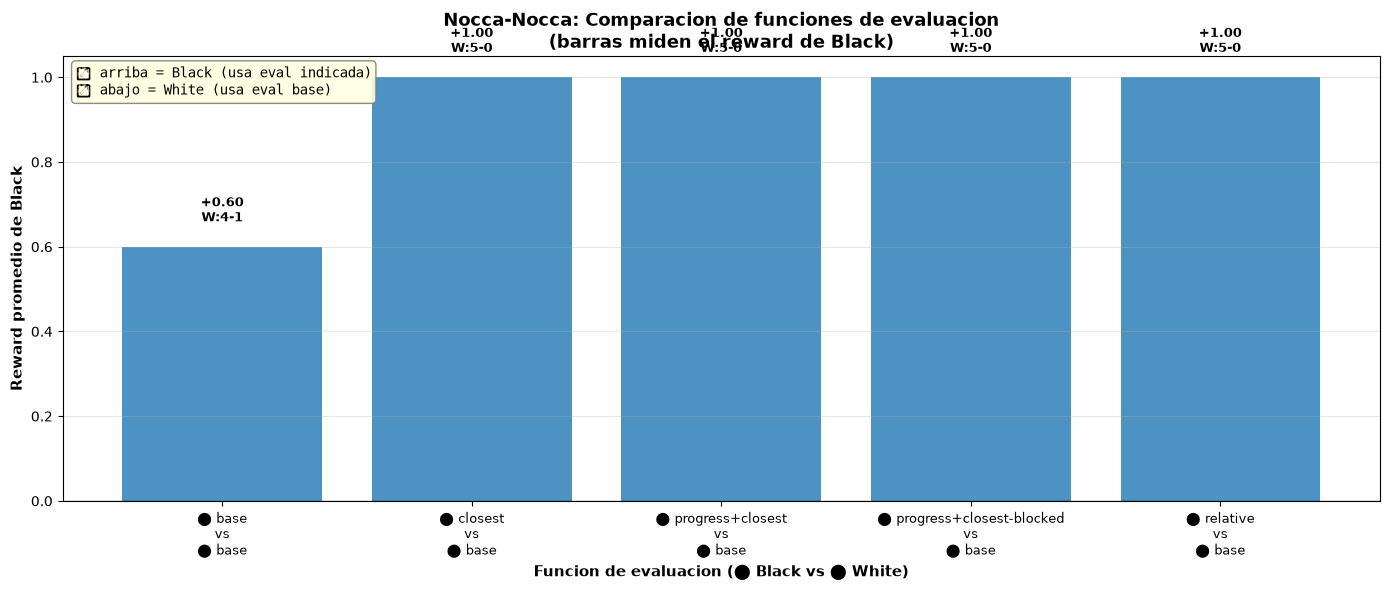


INTERPRETACION
• Black usa la funcion de evaluacion indicada
• White siempre usa la evaluacion 'base' como referencia
• Valores POSITIVOS (azul): la eval de Black supera a 'base'
• Valores NEGATIVOS (rojo): la eval 'base' es mejor

Mejor eval para Black: ⬤ closest vs ⬤ base → +1.00 (wins: 5-0)
Peor eval para Black: ⬤ closest vs ⬤ base → +1.00 (wins: 5-0)


In [16]:
# Visualización de comparación de funciones de evaluación
import matplotlib.pyplot as plt
import numpy as np

EVAL_DEPTH = 1
EVAL_N_GAMES = 5
EVAL_MAX_STEPS = 80
INITIAL_PLAYER = 0

print("Ejecutando comparaciones de funciones de evaluación...")

# Experimentos a visualizar
eval_comparisons = []

# Base vs base (referencia)
wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
    make_game=lambda: NoccaNocca(
        max_steps=EVAL_MAX_STEPS,
        initial_player=INITIAL_PLAYER,
        seed=42,
        render_mode='',
    ),
    make_players=lambda game: {
        game.agents[0]: MiniMaxWithEval(game, game.agents[0], eval_base, depth=EVAL_DEPTH),
        game.agents[1]: MiniMaxWithEval(game, game.agents[1], eval_base, depth=EVAL_DEPTH),
    },
    n_games=EVAL_N_GAMES,
)
eval_comparisons.append({
    'label': f"⬤ base\nvs\n⬤ base",
    'black_avg': avg_rewards[game.agents[0]],
    'wins': wins
})

# Cada eval como Black vs base como White
for eval_name, eval_fn in eval_functions.items():
    if eval_name == 'base':
        continue
    
    wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
        make_game=lambda: NoccaNocca(
            max_steps=EVAL_MAX_STEPS,
            initial_player=INITIAL_PLAYER,
            seed=42,
            render_mode='',
        ),
        make_players=lambda game, eval_fn=eval_fn: {
            game.agents[0]: MiniMaxWithEval(game, game.agents[0], eval_fn, depth=EVAL_DEPTH),
            game.agents[1]: MiniMaxWithEval(game, game.agents[1], eval_base, depth=EVAL_DEPTH),
        },
        n_games=EVAL_N_GAMES,
    )
    eval_comparisons.append({
        'label': f"⬤ {eval_name}\nvs\n⬤ base",
        'black_avg': avg_rewards[game.agents[0]],
        'wins': wins
    })

# Crear visualización
fig, ax = plt.subplots(figsize=(14, 6))
labels = [r['label'] for r in eval_comparisons]
black_values = [r['black_avg'] for r in eval_comparisons]

colors = ['tab:blue' if v >= 0 else 'tab:red' for v in black_values]
bars = ax.bar(labels, black_values, color=colors, alpha=0.8)

# Agregar valores numéricos
for bar, value, result in zip(bars, black_values, eval_comparisons):
    offset = 0.05 if value >= 0 else -0.05
    va = 'bottom' if value >= 0 else 'top'
    wins_text = f"W:{result['wins']['Black']}-{result['wins']['White']}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.2f}\n{wins_text}',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=1, alpha=0.5)

# Caja explicativa
ax.text(
    0.01,
    0.98,
    '⬤ arriba = Black (usa eval indicada)\n⬤ abajo = White (usa eval base)',
    transform=ax.transAxes,
    va='top',
    fontsize=10,
    bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'},
    fontfamily='monospace'
)

ax.set_title('Nocca-Nocca: Comparacion de funciones de evaluacion\n(barras miden el reward de Black)', fontsize=13, fontweight='bold')
ax.set_ylabel('Reward promedio de Black', fontsize=11, fontweight='bold')
ax.set_xlabel('Funcion de evaluacion (⬤ Black vs ⬤ White)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretación
best = max(eval_comparisons[1:], key=lambda r: r['black_avg'])  # Excluir base vs base
worst = min(eval_comparisons[1:], key=lambda r: r['black_avg'])
print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• Black usa la funcion de evaluacion indicada\n"
    f"• White siempre usa la evaluacion 'base' como referencia\n"
    f"• Valores POSITIVOS (azul): la eval de Black supera a 'base'\n"
    f"• Valores NEGATIVOS (rojo): la eval 'base' es mejor\n\n"
    f"Mejor eval para Black: {best['label'].replace(chr(10), ' ')} → {best['black_avg']:+.2f} (wins: {best['wins']['Black']}-{best['wins']['White']})\n"
    f"Peor eval para Black: {worst['label'].replace(chr(10), ' ')} → {worst['black_avg']:+.2f} (wins: {worst['wins']['Black']}-{worst['wins']['White']})\n"
    + '='*80
)

## Heatmap MiniMax en Nocca-Nocca

A diferencia de Tic-Tac-Toe, en esta entrega no usamos una solución analítica ni una estrategia óptima conocida para Nocca-Nocca. El espacio de búsqueda es mucho mayor, por lo que MiniMax profundo se interpreta como una aproximación computacional y no como prueba de equilibrio.

Heatmap de `Black depth` vs `White depth`, usando reward promedio de Black. En Nocca-Nocca el árbol es mucho más grande que en Tic-Tac-Toe; profundidad 8 puede tardar bastante, por eso se deja `HEATMAP_N_GAMES = 1` por defecto. La lectura correcta es comparativa: si al aumentar la profundidad de un jugador mejora su reward promedio, eso sugiere una mejor política empírica bajo esta configuración, pero no garantiza optimalidad global.

Black depth=1 vs White depth=1 | reward Black=1.00 | wins={'Black': 1, 'White': 0, 'draws': 0, 'truncated': 0} | steps=29.0 | tiempo=0.54s
Black depth=1 vs White depth=2 | reward Black=1.00 | wins={'Black': 1, 'White': 0, 'draws': 0, 'truncated': 0} | steps=29.0 | tiempo=6.29s
Black depth=1 vs White depth=3 | reward Black=-1.00 | wins={'Black': 0, 'White': 1, 'draws': 0, 'truncated': 0} | steps=38.0 | tiempo=212.96s
Black depth=2 vs White depth=1 | reward Black=-1.00 | wins={'Black': 0, 'White': 1, 'draws': 0, 'truncated': 0} | steps=36.0 | tiempo=10.07s
Black depth=2 vs White depth=2 | reward Black=-1.00 | wins={'Black': 0, 'White': 1, 'draws': 0, 'truncated': 0} | steps=28.0 | tiempo=14.99s
Black depth=2 vs White depth=3 | reward Black=-1.00 | wins={'Black': 0, 'White': 1, 'draws': 0, 'truncated': 0} | steps=48.0 | tiempo=311.78s
Black depth=3 vs White depth=1 | reward Black=-1.00 | wins={'Black': 0, 'White': 1, 'draws': 0, 'truncated': 0} | steps=30.0 | tiempo=139.33s
Black depth=3 

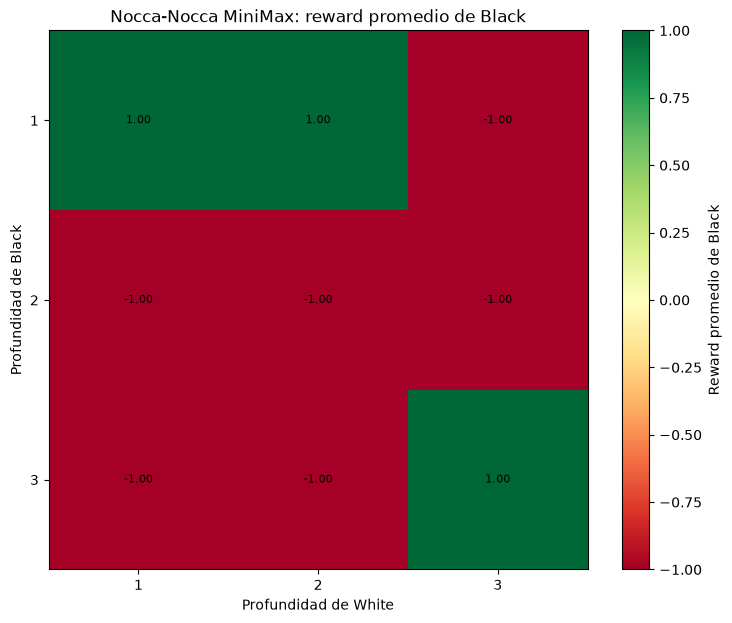

In [17]:
import matplotlib.pyplot as plt

HEATMAP_MAX_DEPTH = 3
HEATMAP_N_GAMES = 1
HEATMAP_MAX_STEPS = 80
HEATMAP_INITIAL_PLAYER = 0

heatmap = np.zeros((HEATMAP_MAX_DEPTH, HEATMAP_MAX_DEPTH))

for depth_black in range(1, HEATMAP_MAX_DEPTH + 1):
    for depth_white in range(1, HEATMAP_MAX_DEPTH + 1):
        wins, avg_rewards, avg_steps, elapsed = summarize_nocca(
            make_game=lambda: NoccaNocca(
                max_steps=HEATMAP_MAX_STEPS,
                initial_player=HEATMAP_INITIAL_PLAYER,
                seed=1,
                render_mode='',
            ),
            make_players=lambda game, depth_black=depth_black, depth_white=depth_white: {
                game.agents[0]: MiniMax(game, game.agents[0], depth=depth_black),
                game.agents[1]: MiniMax(game, game.agents[1], depth=depth_white),
            },
            n_games=HEATMAP_N_GAMES,
        )
        heatmap[depth_black - 1, depth_white - 1] = avg_rewards['Black']
        print(
            f"Black depth={depth_black} vs White depth={depth_white} | "
            f"reward Black={avg_rewards['Black']:.2f} | wins={wins} | "
            f"steps={avg_steps:.1f} | tiempo={elapsed:.2f}s"
        )

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(heatmap, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('Nocca-Nocca MiniMax: reward promedio de Black')
ax.set_xlabel('Profundidad de White')
ax.set_ylabel('Profundidad de Black')
ax.set_xticks(range(HEATMAP_MAX_DEPTH), range(1, HEATMAP_MAX_DEPTH + 1))
ax.set_yticks(range(HEATMAP_MAX_DEPTH), range(1, HEATMAP_MAX_DEPTH + 1))

for i in range(HEATMAP_MAX_DEPTH):
    for j in range(HEATMAP_MAX_DEPTH):
        ax.text(j, i, f'{heatmap[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, label='Reward promedio de Black')
plt.show()

## Visualización de comparaciones de agentes

Los experimentos anteriores muestran resultados en formato texto. A continuación se presenta una visualización gráfica de las comparaciones clave entre diferentes configuraciones de agentes.

Ejecutando comparaciones...
  1/6: ⬤ MiniMax d=1 vs ⬤ Random
  2/6: ⬤ MiniMax d=2 vs ⬤ Random
  3/6: ⬤ Random vs ⬤ MiniMax d=1
  4/6: ⬤ Random vs ⬤ MiniMax d=2
  5/6: ⬤ MCTS s=10,r=2 vs ⬤ Random
  6/6: ⬤ Random vs ⬤ MCTS s=10,r=2


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_3176\3341674645.py:80: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\USUARIO\Documents\ORT\MasterIA\multiagente\Alternating Games\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


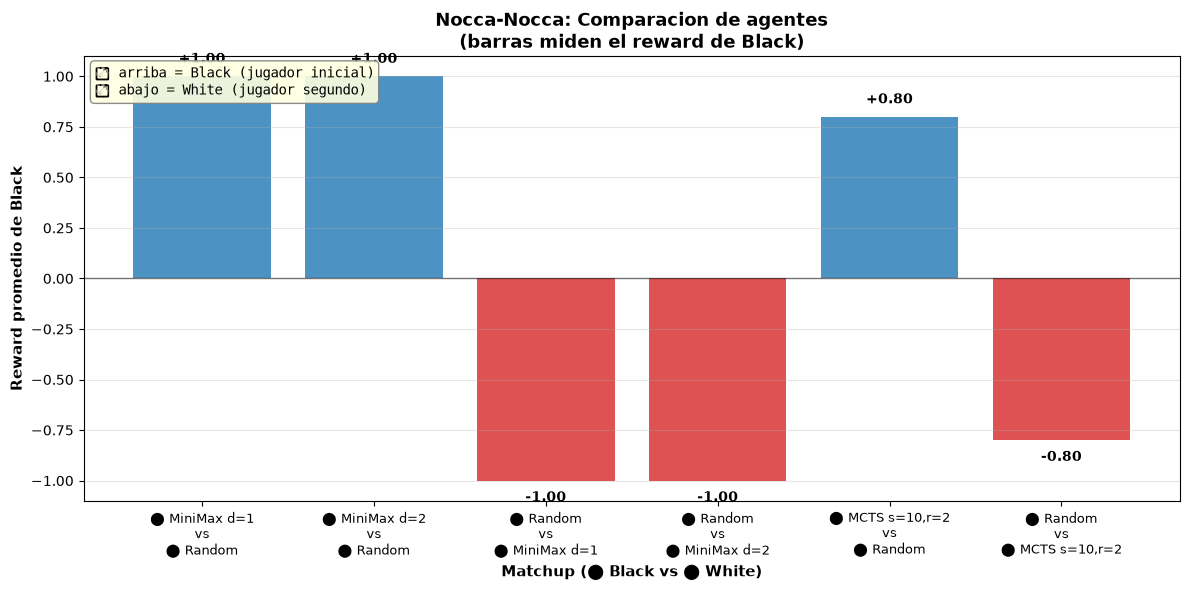


INTERPRETACION
• Black siempre es el PRIMER agente (jugador inicial)
• White siempre es el SEGUNDO agente
• Valores POSITIVOS (azul): Black gana mas
• Valores NEGATIVOS (rojo): White gana mas

Mejor resultado para Black: ⬤ MiniMax d=1 vs vs vs ⬤ Random → +1.00
Peor resultado para Black: ⬤ Random vs vs vs ⬤ MiniMax d=1 → -1.00


In [18]:
# Comparación visual de agentes en Nocca-Nocca
import matplotlib.pyplot as plt
import numpy as np

# Experimentos clave para visualizar
comparison_configs = [
    ("⬤ MiniMax d=1\nvs\n⬤ Random", lambda g: MiniMax(g, g.agents[0], depth=1), lambda g: RandomAgent(g, g.agents[1])),
    ("⬤ MiniMax d=2\nvs\n⬤ Random", lambda g: MiniMax(g, g.agents[0], depth=2), lambda g: RandomAgent(g, g.agents[1])),
    ("⬤ Random\nvs\n⬤ MiniMax d=1", lambda g: RandomAgent(g, g.agents[0]), lambda g: MiniMax(g, g.agents[1], depth=1)),
    ("⬤ Random\nvs\n⬤ MiniMax d=2", lambda g: RandomAgent(g, g.agents[0]), lambda g: MiniMax(g, g.agents[1], depth=2)),
    ("⬤ MCTS s=10,r=2\nvs\n⬤ Random", lambda g: MonteCarloTreeSearch(g, g.agents[0], simulations=10, rollouts=2), lambda g: RandomAgent(g, g.agents[1])),
    ("⬤ Random\nvs\n⬤ MCTS s=10,r=2", lambda g: RandomAgent(g, g.agents[0]), lambda g: MonteCarloTreeSearch(g, g.agents[1], simulations=10, rollouts=2)),
]

results = []
N_EVAL = 5

print("Ejecutando comparaciones...")
for i, (label, make_black, make_white) in enumerate(comparison_configs):
    print(f"  {i+1}/{len(comparison_configs)}: {label.replace(chr(10), ' ')}")
    game = NoccaNocca(max_steps=80, initial_player=0, seed=42, render_mode='')
    
    black_rewards = []
    white_rewards = []
    for _ in range(N_EVAL):
        game.reset()
        players = {game.agents[0]: make_black(game), game.agents[1]: make_white(game)}
        while not game.game_over():
            game.step(players[game.agent_selection].action())
        black_rewards.append(game.reward(game.agents[0]))
        white_rewards.append(game.reward(game.agents[1]))
    
    results.append({
        'label': label,
        'black_avg': np.mean(black_rewards),
        'white_avg': np.mean(white_rewards),
    })

# Crear visualización
fig, ax = plt.subplots(figsize=(12, 6))
labels = [r['label'] for r in results]
black_values = [r['black_avg'] for r in results]

colors = ['tab:blue' if v >= 0 else 'tab:red' for v in black_values]
bars = ax.bar(labels, black_values, color=colors, alpha=0.8)

# Agregar valores numéricos
for bar, value in zip(bars, black_values):
    offset = 0.05 if value >= 0 else -0.05
    va = 'bottom' if value >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.2f}',
        ha='center',
        va=va,
        fontsize=10,
        fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=1, alpha=0.5)

# Caja explicativa
ax.text(
    0.01,
    0.98,
    '⬤ arriba = Black (jugador inicial)\n⬤ abajo = White (jugador segundo)',
    transform=ax.transAxes,
    va='top',
    fontsize=10,
    bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'},
    fontfamily='monospace'
)

ax.set_title('Nocca-Nocca: Comparacion de agentes\n(barras miden el reward de Black)', fontsize=13, fontweight='bold')
ax.set_ylabel('Reward promedio de Black', fontsize=11, fontweight='bold')
ax.set_xlabel('Matchup (⬤ Black vs ⬤ White)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretación
best = max(results, key=lambda r: r['black_avg'])
worst = min(results, key=lambda r: r['black_avg'])
print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• Black siempre es el PRIMER agente (jugador inicial)\n"
    f"• White siempre es el SEGUNDO agente\n"
    f"• Valores POSITIVOS (azul): Black gana mas\n"
    f"• Valores NEGATIVOS (rojo): White gana mas\n\n"
    f"Mejor resultado para Black: {best['label'].replace(chr(10), ' vs ')} → {best['black_avg']:+.2f}\n"
    f"Peor resultado para Black: {worst['label'].replace(chr(10), ' vs ')} → {worst['black_avg']:+.2f}\n"
    + '='*80
)

## Alpha-Beta Pruning

Alpha-Beta es una optimización de Minimax que poda ramas del árbol que nunca pueden afectar la decisión final:

- **Poda β (nodo Min):** si el Min ya encontró un valor ≤ α (lo mejor que el Max puede garantizarse), el Max nunca elegiría esa rama → se descarta.  
- **Poda α (nodo Max):** si el Max ya encontró un valor ≥ β (lo mejor que el Min puede garantizarse), el Min nunca elegiría esa rama → se descarta.

El valor óptimo **no cambia**; solo se reducen los nodos explorados.

### Reducción teórica (factor de ramificación b ≈ 30 en Nocca-Nocca)

| Profundidad | Minimax (nodos) | Alpha-Beta mejor caso | Speedup teórico |
|:-----------:|:---------------:|:--------------------:|:---------------:|
| 1 | ~30 | ~30 | 1× |
| 2 | ~900 | ~30 | **~30×** |
| 3 | ~27 000 | ~164 | **~165×** |
| 4 | ~810 000 | ~900 | **~900×** |

### ¿Qué pasa con profundidad sin límite?

El árbol de Nocca-Nocca tiene hasta ~30^150 nodos (partida de 150 turnos). Con Alpha-Beta se reduce a ~30^75. **Ambos son computacionalmente inviables**: la búsqueda nunca terminaría. La ganancia práctica de Alpha-Beta es poder usar profundidades mayores (3, 4, 5…) en tiempo razonable.

In [1]:
import sys
import numpy as np
from time import perf_counter

from base.agent import Agent, AgentID
from base.game import AlternatingGame
from games.nocca_nocca.nocca_nocca import NoccaNocca
from agents.minimax import MiniMax


# ── Implementación: Alpha-Beta Pruning ───────────────────────────────────────
class AlphaBeta(Agent):
    """
    Minimax con poda Alpha-Beta.

    Explora el mismo árbol que MiniMax pero descarta («poda») ramas que
    nunca podrían cambiar la decisión final:

      - Poda α (nodo Max): si el Max ya aseguró un valor ≥ β,
        el Min no elegiría esta rama → se corta.
      - Poda β (nodo Min): si el Min ya aseguró un valor ≤ α,
        el Max no elegiría esta rama → se corta.

    El resultado (acción óptima y valor) es idéntico al de MiniMax estándar.
    """

    def __init__(self, game: AlternatingGame, agent: AgentID,
                 seed=None, depth: int = sys.maxsize) -> None:
        super().__init__(game, agent)
        if depth < 0:
            raise ValueError("Depth must be a non-negative integer.")
        self.depth = depth
        self.seed = seed
        np.random.seed(seed)

    def action(self):
        act, _ = self.alphabeta(self.game, self.depth, float('-inf'), float('inf'))
        return act

    def alphabeta(self, game: AlternatingGame, depth: int,
                  alpha: float, beta: float):
        agent = game.agent_selection
        chosen_action = None

        # ── Casos base ───────────────────────────────────────────────────
        if game.terminated():
            return None, game.reward(self.agent)
        if depth == 0:
            return None, self.eval(game)

        # ── Casos recursivos ─────────────────────────────────────────────
        actions = game.available_actions()
        np.random.shuffle(actions)          # desempate aleatorio

        if agent != self.agent:             # nodo Min
            value = float('inf')
            for action in actions:
                child = game.clone()
                child.step(action)
                _, child_val = self.alphabeta(child, depth - 1, alpha, beta)
                if child_val < value:
                    value = child_val
                    chosen_action = action
                beta = min(beta, value)
                if alpha >= beta:
                    break                   # poda β
        else:                               # nodo Max
            value = float('-inf')
            for action in actions:
                child = game.clone()
                child.step(action)
                _, child_val = self.alphabeta(child, depth - 1, alpha, beta)
                if child_val > value:
                    value = child_val
                    chosen_action = action
                alpha = max(alpha, value)
                if alpha >= beta:
                    break                   # poda α

        return chosen_action, value

    def eval(self, game: AlternatingGame):
        return game.eval(self.agent)


# ── Comparación de tiempos: MiniMax vs AlphaBeta ─────────────────────────────
DEPTHS  = [1, 2, 3]   # profundidades a comparar
N_MOVES = 5           # movimientos a promediar por profundidad

print("Comparación de tiempo por movimiento: MiniMax vs Alpha-Beta")
print("=" * 65)
print(f"{'Profundidad':>12}  {'MiniMax (s)':>12}  {'Alpha-Beta (s)':>15}  {'Speedup':>8}")
print("-" * 65)

for depth in DEPTHS:
    times_mm, times_ab = [], []

    for trial in range(N_MOVES):
        # MiniMax
        g = NoccaNocca(max_steps=80, initial_player=0, seed=trial, render_mode='')
        g.reset()
        agent = MiniMax(game=g, agent=g.agents[0], depth=depth)
        t0 = perf_counter()
        agent.action()
        times_mm.append(perf_counter() - t0)

        # Alpha-Beta
        g = NoccaNocca(max_steps=80, initial_player=0, seed=trial, render_mode='')
        g.reset()
        agent = AlphaBeta(game=g, agent=g.agents[0], depth=depth)
        t0 = perf_counter()
        agent.action()
        times_ab.append(perf_counter() - t0)

    avg_mm = np.mean(times_mm)
    avg_ab = np.mean(times_ab)
    speedup = avg_mm / avg_ab if avg_ab > 1e-9 else float('inf')
    print(f"{depth:>12}  {avg_mm:>12.4f}  {avg_ab:>15.4f}  {speedup:>8.2f}×")

print("=" * 65)
print()
print("NOTA: La poda reduce O(b^d) → O(b^(d/2)) en el mejor caso.")
print("      Para profundidad SIN LÍMITE en Nocca-Nocca, el árbol")
print("      completo tiene ≈30^150 nodos; con Alpha-Beta ≈30^75.")
print("      Ambos son inviables: la búsqueda nunca terminaría.")
print("      La ganancia real de Alpha-Beta es usar depth=3 o 4")
print("      en tiempo similar a depth=1 o 2 con Minimax estándar.")

Comparación de tiempo por movimiento: MiniMax vs Alpha-Beta
 Profundidad   MiniMax (s)   Alpha-Beta (s)   Speedup
-----------------------------------------------------------------
           1        0.0067           0.0033      2.06×
           2        0.0727           0.0145      5.00×
           3        1.7091           0.0948     18.03×

NOTA: La poda reduce O(b^d) → O(b^(d/2)) en el mejor caso.
      Para profundidad SIN LÍMITE en Nocca-Nocca, el árbol
      completo tiene ≈30^150 nodos; con Alpha-Beta ≈30^75.
      Ambos son inviables: la búsqueda nunca terminaría.
      La ganancia real de Alpha-Beta es usar depth=3 o 4
      en tiempo similar a depth=1 o 2 con Minimax estándar.
